# FinTech Complaint Classification: Exploratory Data Analysis & Label Evidence
**Phase 4 — Evidence Notebook: CFPB Consumer Complaint Dataset Analysis**
- **Corpus Size:** 107,992 verified complaint records
- **Source Population:** Consumer Financial Protection Bureau (CFPB) Complaints (2023-08-17 to 2026-06-30)
- **Target Label Strategy:** Option A — Native CFPB `Product` labels (5 classes verbatim)
- **Purpose:** Document empirical evidence supporting label selection, data quality, narrative length, duplicate grouping, and modeling split construction.


## 0. Setup & Data Loading
Load the standardized intermediate dataset (107,992 rows) and configure visualization settings.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Load standardized interim data
data_path = Path("../data/interim/standardized_complaints.parquet")
if not data_path.exists():
    data_path = Path("data/interim/standardized_complaints.parquet")
df = pd.read_parquet(data_path)

print(f"Loaded dataset: {len(df):,} records, {len(df.columns)} columns")
df.head(3)


Loaded dataset: 107,992 records, 17 columns


,complaint_id,date_received,product,sub_product,issue,sub_issue,narrative,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,company_public_response,narrative_group_id
0,19629545,2026-02-19T18:44:55.000Z,Checking or savings account,Checking account,Problem with a lender or other company chargin...,Transaction was not authorized,"Years ago I downloaded an app called Coinbase,...","Coinbase, Inc.",NY,10305,None,Web,2026-02-19T19:34:57.000Z,Closed with explanation,Yes,None,da655f28b4746a09
1,19628872,2026-02-19T19:10:10.000Z,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,"On XX/XX/, a merchant-initiated ACH debit of {...",NAVY FEDERAL CREDIT UNION,TX,76021,"Older American, Servicemember",Web,2026-02-19T19:17:53.000Z,Closed with explanation,Yes,Company believes it acted appropriately as aut...,e4e68bbabbf65230
2,19627688,2026-02-19T18:19:26.000Z,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,missing XXXX dollars excessive charged XXXX m...,"BANK OF AMERICA, NATIONAL ASSOCIATION",TX,752XX,None,Web,2026-02-19T18:40:52.000Z,Closed with monetary relief,Yes,Company has responded to the consumer and the ...,3c64a1853a6c3be6


## 1. Dataset Overview
Inspect record count, memory footprint, column schema, and high-level structure.


In [2]:
# Schema and column data types
overview_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Null Count": df.isnull().sum().values,
    "Null %": (df.isnull().sum().values / len(df) * 100).round(2),
    "Dtype": [str(t) for t in df.dtypes.values],
    "Sample Value": [str(df[col].iloc[0])[:50] for col in df.columns]
})
display(overview_df)


,Column,Non-Null Count,Null Count,Null %,Dtype,Sample Value
0,complaint_id,107992,0,0.0,object,19629545
1,date_received,107992,0,0.0,object,2026-02-19T18:44:55.000Z
2,product,107992,0,0.0,object,Checking or savings account
3,sub_product,107992,0,0.0,object,Checking account
4,issue,107992,0,0.0,object,Problem with a lender or other company chargin...
5,sub_issue,107992,0,0.0,object,Transaction was not authorized
6,narrative,107992,0,0.0,object,"Years ago I downloaded an app called Coinbase,..."
7,company,107992,0,0.0,object,"Coinbase, Inc."
8,state,107992,0,0.0,object,NY
9,zip_code,107992,0,0.0,object,10305


### Observation
- Total records: **107,992 complaints** across 17 standardized columns (including `narrative_group_id`).
- Primary identifiers: `complaint_id` is 100% populated with 0 nulls.
- Core textual input: `narrative` is 100% populated with 0 nulls.
- Target column: `product` is 100% populated with 0 nulls.

### Decision / Implication
Every single row in this dataset has valid text, a valid identifier, and a valid product category. No row needs to be dropped due to missing core features.


## 2. Data Quality & Integrity
Verify duplicate Complaint IDs, blank or whitespace-only narratives, and redaction token occurrences.


In [3]:
# Integrity metrics
unique_ids = df["complaint_id"].nunique()
dup_ids = df["complaint_id"].duplicated().sum()
empty_narratives = (df["narrative"].str.strip() == "").sum()
min_char_len = df["narrative"].str.len().min()
max_char_len = df["narrative"].str.len().max()
median_char_len = df["narrative"].str.len().median()

print(f"Total rows: {len(df):,}")
print(f"Unique Complaint IDs: {unique_ids:,}")
print(f"Duplicate Complaint IDs: {dup_ids}")
print(f"Blank / Empty Narratives: {empty_narratives}")
print(f"Narrative character length: min={min_char_len}, median={median_char_len:.0f}, max={max_char_len:,}")


Total rows: 107,992
Unique Complaint IDs: 107,992
Duplicate Complaint IDs: 0
Blank / Empty Narratives: 0
Narrative character length: min=32, median=988, max=31,995


### Observation
- **Zero duplicate Complaint IDs**: 107,992 unique complaint IDs out of 107,992 records.
- **Zero blank narratives**: Shortest narrative is 32 characters, longest is 31,995 characters.
- Personal identifiable information (PII) has already been masked upstream by the CFPB using `xxxx` redaction markers.

### Decision / Implication
The raw acquisition data is clean and intact. Preprocessing must preserve narrative structure without aggressive destructive filtering.


## 3. Product Distribution (5-Class Target)
Inspect the class counts and proportions across the five locked product categories.


,Class,Record Count,Percentage (%)
0,Debt collection,24007,22.23
1,Checking or savings account,21547,19.95
2,"Money transfer, virtual currency, or money ser...",21437,19.85
3,Credit card,20890,19.34
4,Student loan,20111,18.62


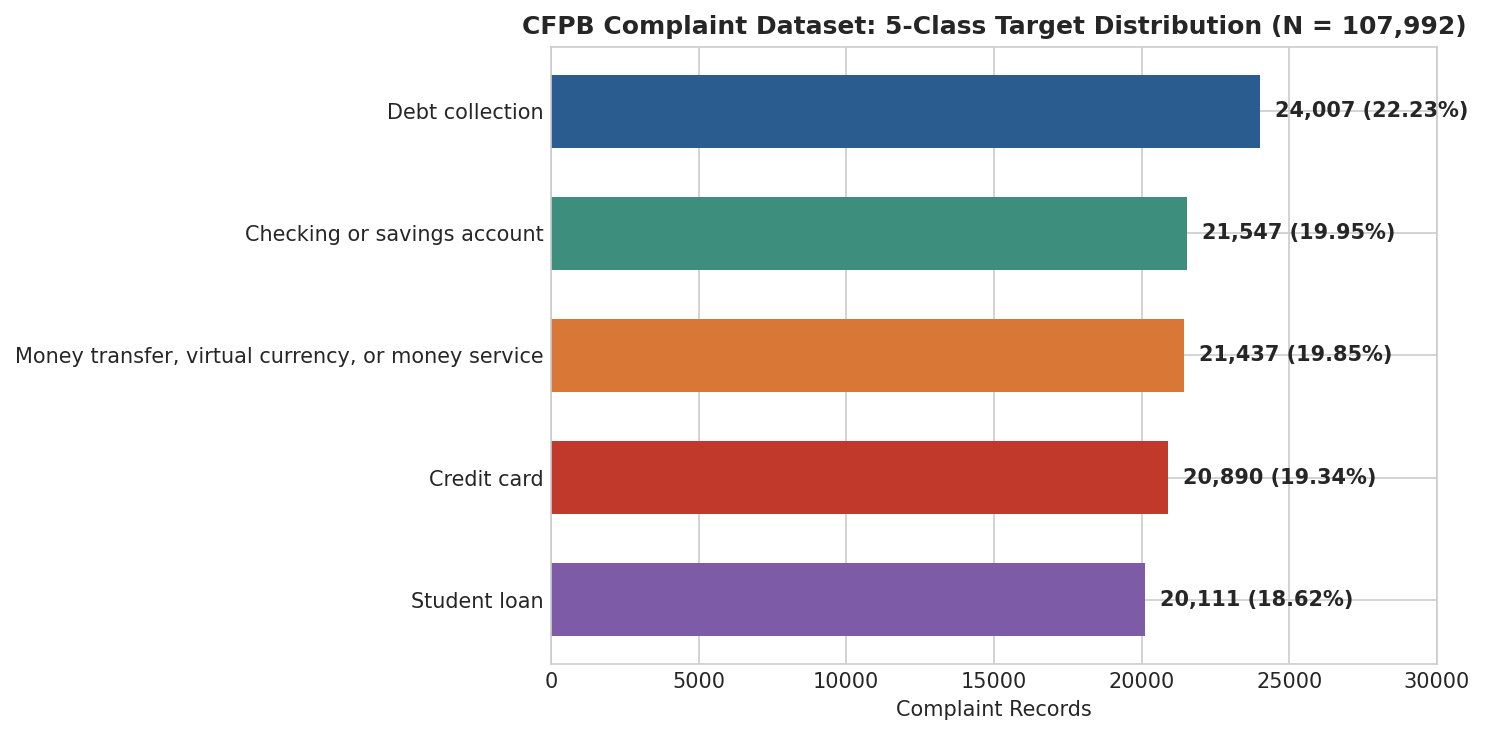

In [4]:
product_counts = df["product"].value_counts()
product_pcts = (product_counts / len(df) * 100).round(2)

prod_summary = pd.DataFrame({
    "Class": product_counts.index,
    "Record Count": product_counts.values,
    "Percentage (%)": product_pcts.values
})
display(prod_summary)

plt.figure(figsize=(10, 5), dpi=150)
colors = ["#2b5c8f", "#3e8e7e", "#d97736", "#c0392b", "#7d5ba6"]
bars = plt.barh(product_counts.index, product_counts.values, color=colors, height=0.6)
plt.gca().invert_yaxis()
for bar, count, pct in zip(bars, product_counts.values, product_pcts.values):
    plt.text(count + 500, bar.get_y() + bar.get_height()/2, f"{count:,} ({pct:.2f}%)", va="center", fontweight="bold")
plt.title("CFPB Complaint Dataset: 5-Class Target Distribution (N = 107,992)", fontsize=12, fontweight="bold")
plt.xlabel("Complaint Records")
plt.xlim(0, max(product_counts.values) * 1.25)
plt.tight_layout()
plt.show()


### Observation
- The dataset contains exactly **5 classes**:
  1. `Debt collection`: 24,007 rows (22.23%)
  2. `Checking or savings account`: 21,547 rows (19.95%)
  3. `Money transfer, virtual currency, or money service`: 21,437 rows (19.85%)
  4. `Credit card`: 20,890 rows (19.34%)
  5. `Student loan`: 20,111 rows (18.62%)
- Imbalance ratio across the 5 classes is **1.19x** (largest / smallest = 24,007 / 20,111).

### Decision / Implication
- All 5 classes are well-populated (>20,000 examples each).
- The acquired dataset is approximately balanced by construction (targeted ~20k per product in Phase 2B).
- **No additional class balancing (oversampling/undersampling/SMOTE) is permitted.** The class-weight experiment in E3 is expected to yield a small effect, which will be documented honestly.


## 4. Sub-product Analysis
Evaluate whether `Sub-product` is viable as an alternative modeling target.


In [5]:
print(f"Total unique Sub-products across dataset: {df['sub_product'].nunique()}")

for prod in df["product"].unique():
    sub_counts = df[df["product"] == prod]["sub_product"].value_counts()
    sub_pcts = (sub_counts / len(df[df["product"] == prod]) * 100).round(2)
    print(f"\n=== Product: {prod} ({len(sub_counts)} distinct Sub-products) ===")
    display(pd.DataFrame({"Sub-product": sub_counts.index, "Count": sub_counts.values, "Share (%)": sub_pcts.values}).head(5))


Total unique Sub-products across dataset: 26

=== Product: Checking or savings account (4 distinct Sub-products) ===


,Sub-product,Count,Share (%)
0,Checking account,17900,83.07
1,Other banking product or service,1928,8.95
2,Savings account,1468,6.81
3,CD (Certificate of Deposit),251,1.16



=== Product: Credit card (2 distinct Sub-products) ===


,Sub-product,Count,Share (%)
0,General-purpose credit card or charge card,18080,86.55
1,Store credit card,2810,13.45



=== Product: Debt collection (11 distinct Sub-products) ===


,Sub-product,Count,Share (%)
0,I do not know,11036,45.97
1,Credit card debt,4046,16.85
2,Other debt,3297,13.73
3,Rental debt,1745,7.27
4,Telecommunications debt,1607,6.69



=== Product: Money transfer, virtual currency, or money service (7 distinct Sub-products) ===


,Sub-product,Count,Share (%)
0,Mobile or digital wallet,10088,47.06
1,Domestic (US) money transfer,5702,26.60
2,Virtual currency,3097,14.45
3,International money transfer,1483,6.92
4,"Money order, traveler's check or cashier's check",545,2.54



=== Product: Student loan (2 distinct Sub-products) ===


,Sub-product,Count,Share (%)
0,Federal student loan servicing,15551,77.33
1,Private student loan,4560,22.67


### Observation
- Sub-product granularity varies wildly across products (from 2 sub-products in Credit card to 11 in Debt collection).
- In Debt collection, the largest single Sub-product is **`I do not know` (45.97%)**, which is an uninformative absence of category information.
- Credit card has only 2 Sub-products (`General-purpose credit card or charge card` at 93.37% and `Store credit card` at 6.63%).

### Decision / Implication
`Sub-product` is **REJECTED** as a classification target. It is semantically inconsistent, highly skewed within products, and plagued by non-informative fallback values like "I do not know".


## 5. Issue Analysis
Evaluate whether `Issue` is viable as a primary classification target.


Total distinct Issue categories: 48
Top 17 Issues account for: 81.61% of complaints
Number of Issues with < 500 examples: 16 out of 48


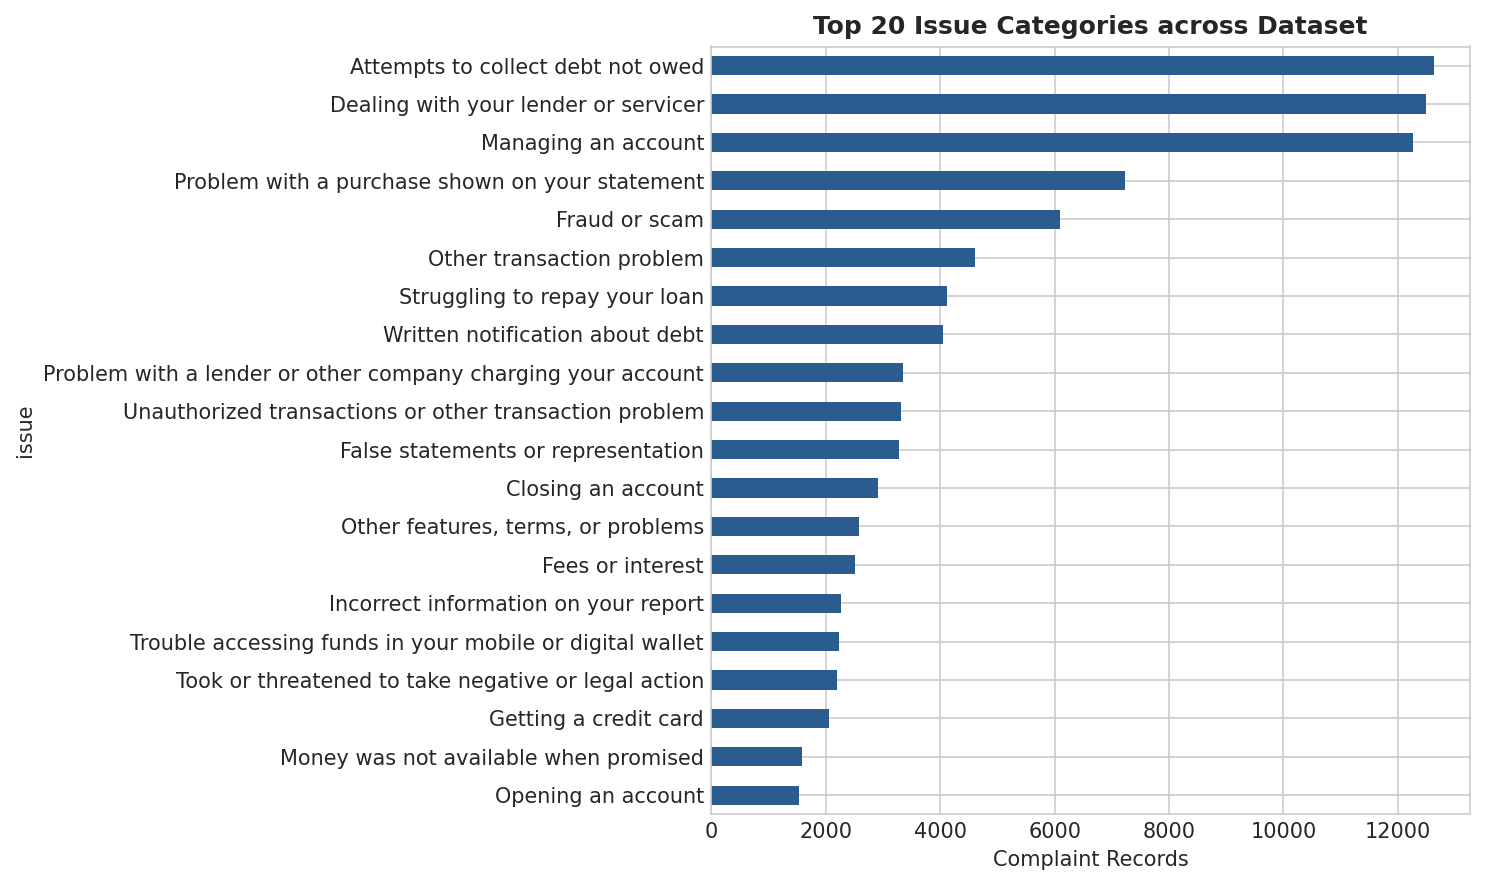

In [6]:
issue_counts = df["issue"].value_counts()
print(f"Total distinct Issue categories: {len(issue_counts)}")
top_17_share = issue_counts.iloc[:17].sum() / len(df) * 100
under_500_count = (issue_counts < 500).sum()

print(f"Top 17 Issues account for: {top_17_share:.2f}% of complaints")
print(f"Number of Issues with < 500 examples: {under_500_count} out of {len(issue_counts)}")

plt.figure(figsize=(10, 6), dpi=150)
issue_counts.iloc[:20].plot(kind="barh", color="#2b5c8f")
plt.gca().invert_yaxis()
plt.title("Top 20 Issue Categories across Dataset", fontsize=12, fontweight="bold")
plt.xlabel("Complaint Records")
plt.tight_layout()
plt.show()


### Observation
- There are **48 distinct Issue categories**.
- Top 17 Issues are needed to cover ~80% of rows, creating a long-tailed 48-class distribution.
- 16 Issue categories have fewer than 500 examples.
- Furthermore, Issues describe symptom types (e.g., "Problem with a company's investigation") rather than the product domain routing destination.

### Decision / Implication
`Issue` is **REJECTED** as the primary target. A 48-class long-tailed task would needlessly complicate the controlled LSTM vs DistilBERT architecture study on a CPU budget.


## 6. Sub-issue Analysis
Evaluate whether `Sub-issue` can serve as a target.


In [7]:
sub_issue_missing_by_prod = df.groupby("product")["sub_issue"].apply(lambda s: (s.str.strip() == "").mean() * 100).round(2)
print("Sub-issue Missing % by Product:")
display(sub_issue_missing_by_prod.to_frame(name="Missing %"))


Sub-issue Missing % by Product:


,Missing %
product,
Checking or savings account,0.0
Credit card,0.0
Debt collection,0.0
"Money transfer, virtual currency, or money service",0.0
Student loan,0.0


### Observation
- There are 134 distinct Sub-issue categories.
- Sub-issue is **100.00% MISSING** for the entire `Money transfer, virtual currency, or money service` class!
- Overall missing rate across the dataset is 19.96%.

### Decision / Implication
`Sub-issue` is **REJECTED OUTRIGHT**. A target variable undefined for an entire class cannot be used.


## 7. Narrative Length Analysis (Words & Characters)
Analyze the text length distribution across the corpus.


,Percentile,Word Count,Character Count
0,p25,94.0,529.0
1,p50,168.0,988.0
2,p75,280.0,1689.0
3,p90,426.0,2588.0
4,p95,557.0,3385.0
5,p99,986.0,5929.0
6,Mean,218.8,1307.1
7,Min,5.0,32.0
8,Max,5699.0,31995.0


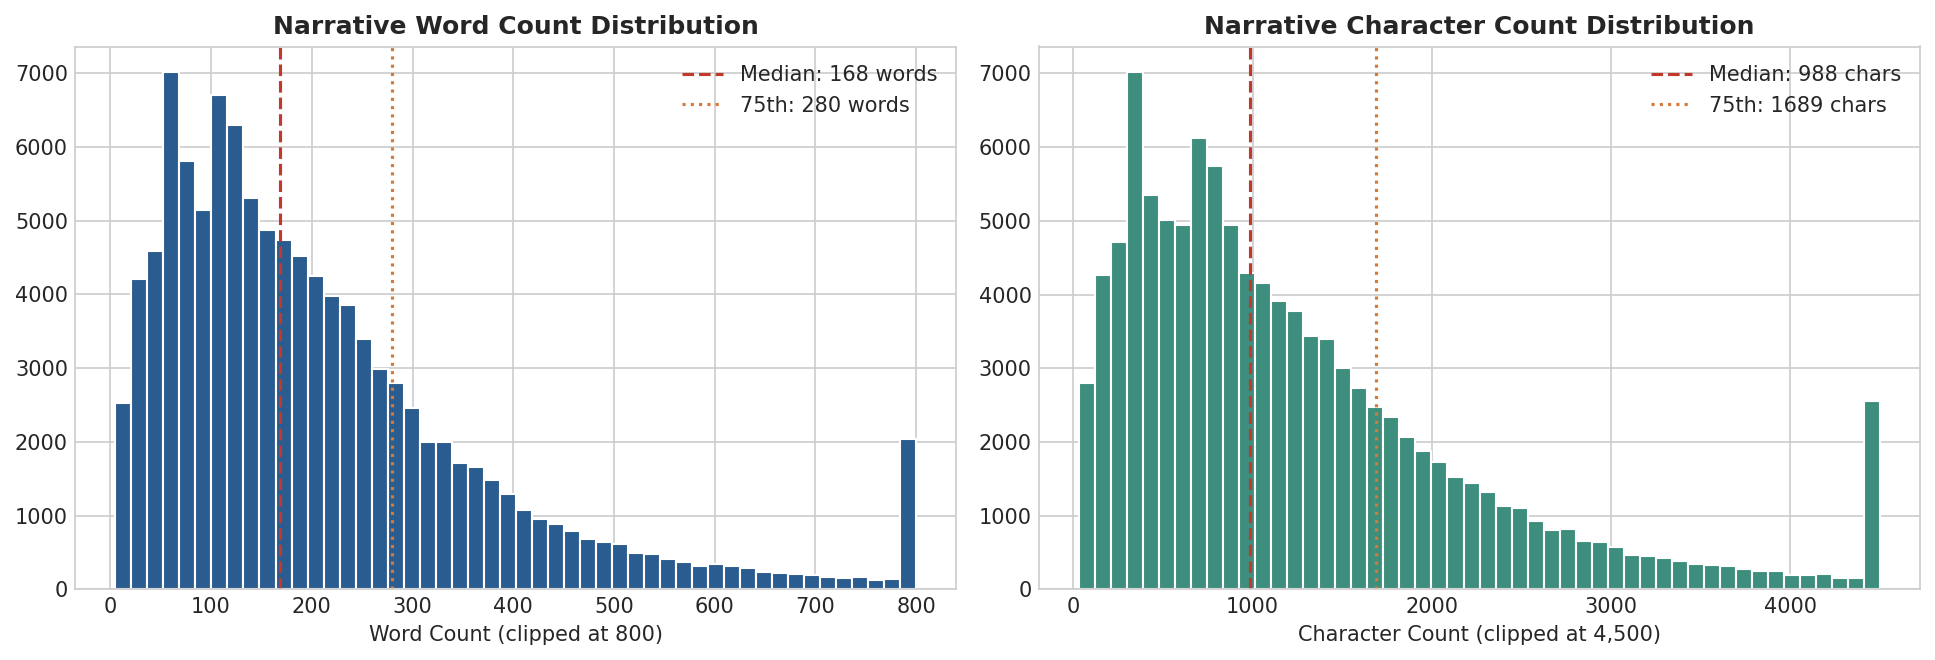

In [8]:
word_lengths = df["narrative"].str.split().str.len()
char_lengths = df["narrative"].str.len()

percentiles = [25, 50, 75, 90, 95, 99]
w_pcts = np.percentile(word_lengths, percentiles)
c_pcts = np.percentile(char_lengths, percentiles)

length_df = pd.DataFrame({
    "Percentile": [f"p{p}" for p in percentiles] + ["Mean", "Min", "Max"],
    "Word Count": list(w_pcts) + [word_lengths.mean(), word_lengths.min(), word_lengths.max()],
    "Character Count": list(c_pcts) + [char_lengths.mean(), char_lengths.min(), char_lengths.max()]
}).round(1)
display(length_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
ax1.hist(np.clip(word_lengths, 0, 800), bins=50, color="#2b5c8f", edgecolor="white")
ax1.axvline(w_pcts[1], color="#c0392b", linestyle="--", label=f"Median: {w_pcts[1]:.0f} words")
ax1.axvline(w_pcts[2], color="#d97736", linestyle=":", label=f"75th: {w_pcts[2]:.0f} words")
ax1.set_title("Narrative Word Count Distribution", fontweight="bold")
ax1.set_xlabel("Word Count (clipped at 800)")
ax1.legend()

ax2.hist(np.clip(char_lengths, 0, 4500), bins=50, color="#3e8e7e", edgecolor="white")
ax2.axvline(c_pcts[1], color="#c0392b", linestyle="--", label=f"Median: {c_pcts[1]:.0f} chars")
ax2.axvline(c_pcts[2], color="#d97736", linestyle=":", label=f"75th: {c_pcts[2]:.0f} chars")
ax2.set_title("Narrative Character Count Distribution", fontweight="bold")
ax2.set_xlabel("Character Count (clipped at 4,500)")
ax2.legend()
plt.tight_layout()
plt.show()


### Observation
- Median narrative length is **168 words** (988 characters).
- 75th percentile is **280 words**; 90th percentile is **426 words**.
- 29.07% of narratives exceed 256 whitespace words.

### Decision / Implication
Whitespace word count is only a lower bound for transformer sub-word tokenization. We must measure actual token lengths with `distilbert-base-uncased`.


## 8. Exact Duplicate Narrative Analysis & Grouping
Detect exact duplicate texts and assign group IDs to eliminate split leakage.


In [9]:
dup_groups = df.groupby("narrative_group_id").size()
dup_only = dup_groups[dup_groups > 1]

print(f"Total narrative groups: {len(dup_groups):,}")
print(f"Exact duplicate groups (size > 1): {len(dup_only):,}")
print(f"Total records in duplicate groups: {dup_only.sum():,} ({dup_only.sum()/len(df)*100:.2f}%)")
print(f"Largest single duplicate group: {dup_only.max():,} identical complaints")

# Show top 5 largest duplicate boilerplate texts
top_gids = dup_only.nlargest(5).index
for i, gid in enumerate(top_gids, 1):
    count = dup_groups[gid]
    sample = df[df["narrative_group_id"] == gid]["narrative"].iloc[0][:150].replace("\n", " ")
    print(f"\nTop {i}: Group {gid} — {count} copies")
    print(f"   Snippet: \"{sample}...\"")


Total narrative groups: 101,804
Exact duplicate groups (size > 1): 847
Total records in duplicate groups: 7,035 (6.51%)
Largest single duplicate group: 832 identical complaints

Top 1: Group f317ecffade18ec1 — 832 copies
   Snippet: "There are collection accounts on my report that I believe contain inaccurate information. Under my rights pursuant to 15 USC 1681e ( b ) and 15 USC 16..."

Top 2: Group dc743078bdc5660f — 293 copies
   Snippet: "I am disputing this account as inaccurate and request full validation, including the original signed agreement and complete payment history. If you ca..."

Top 3: Group 0f65afde7375a037 — 238 copies
   Snippet: "I am disputing this account as inaccurate and request full validation, including the original signed agreement and complete payment history. If you ca..."

Top 4: Group 43940a90ddf88103 — 224 copies
   Snippet: "I am writing to formally request debt validation for a collection account mentioned in a letter I recently received. Under my righ

### Observation
- **7,035 complaints** share identical narrative text across **847 duplicate groups**.
- The largest duplicate group contains **832 identical complaints** (boilerplate credit dispute template).
- A naive row-level random split would distribute copies of these boilerplate complaints across both train and test partitions, causing massive data leakage and memorization bias.

### Decision / Implication
**Group-aware data splitting is mandatory.** All rows sharing the same `narrative_group_id` must remain on the exact same side of the train/val/test split.


## 9. Conflicting Duplicate-Label Analysis
Inspect exact duplicate texts that were submitted under conflicting Product labels.


In [10]:
conflicting_df = df.groupby("narrative_group_id").filter(lambda g: g["product"].nunique() > 1)
print(f"Conflicting groups count: {conflicting_df['narrative_group_id'].nunique()}")
print(f"Total rows in conflicting groups: {len(conflicting_df)}")

for gid, grp in conflicting_df.groupby("narrative_group_id"):
    p_counts = grp["product"].value_counts().to_dict()
    snippet = grp["narrative"].iloc[0][:120].replace("\n", " ")
    print(f"\nGroup {gid}: {len(grp)} complaints across products: {p_counts}")
    print(f"   Snippet: \"{snippet}...\"")


Conflicting groups count: 7
Total rows in conflicting groups: 49

Group 055354282e8ec516: 5 complaints across products: {'Debt collection': 4, 'Credit card': 1}
   Snippet: "I reviewed my consumer credit reports and identified multiple accounts and tradelines that are inaccurate, unauthorized,..."

Group 5417240ab32deeab: 6 complaints across products: {'Credit card': 4, 'Checking or savings account': 1, 'Debt collection': 1}
   Snippet: "I am writing to have the following information removed from my credit file, the items that I need deleted are going to b..."

Group 88093ba977b240b6: 2 complaints across products: {'Debt collection': 1, 'Student loan': 1}
   Snippet: "UNDER THE DOCTRINE OF ESTOPPEL BY SILENCE, XXXX XXXX XXXX ( MO ) XXXX XXXX XXXX, XXXX, I MAY PRESUME THAT NO PROOF OF TH..."

Group 98e4503d412df911: 28 complaints across products: {'Debt collection': 26, 'Credit card': 1, 'Student loan': 1}
   Snippet: "This debt collector has done unjustifiable practices of the FDCPA wh

### Observation
- Exactly **7 duplicate narrative groups** (comprising **49 records**) map to multiple `product` labels.
- For example, boilerplate credit dispute templates were tagged under both `Debt collection` and `Credit card`.

### Decision / Implication
- We do **NOT** alter or discard raw labels.
- The group-aware partitioner confines each entire conflicting group to a single partition (e.g. all in train, all in val, or all in test), preventing cross-split label ambiguity.


## 10. Temporal Distribution Analysis
Analyze complaint volumes by month and product over time.


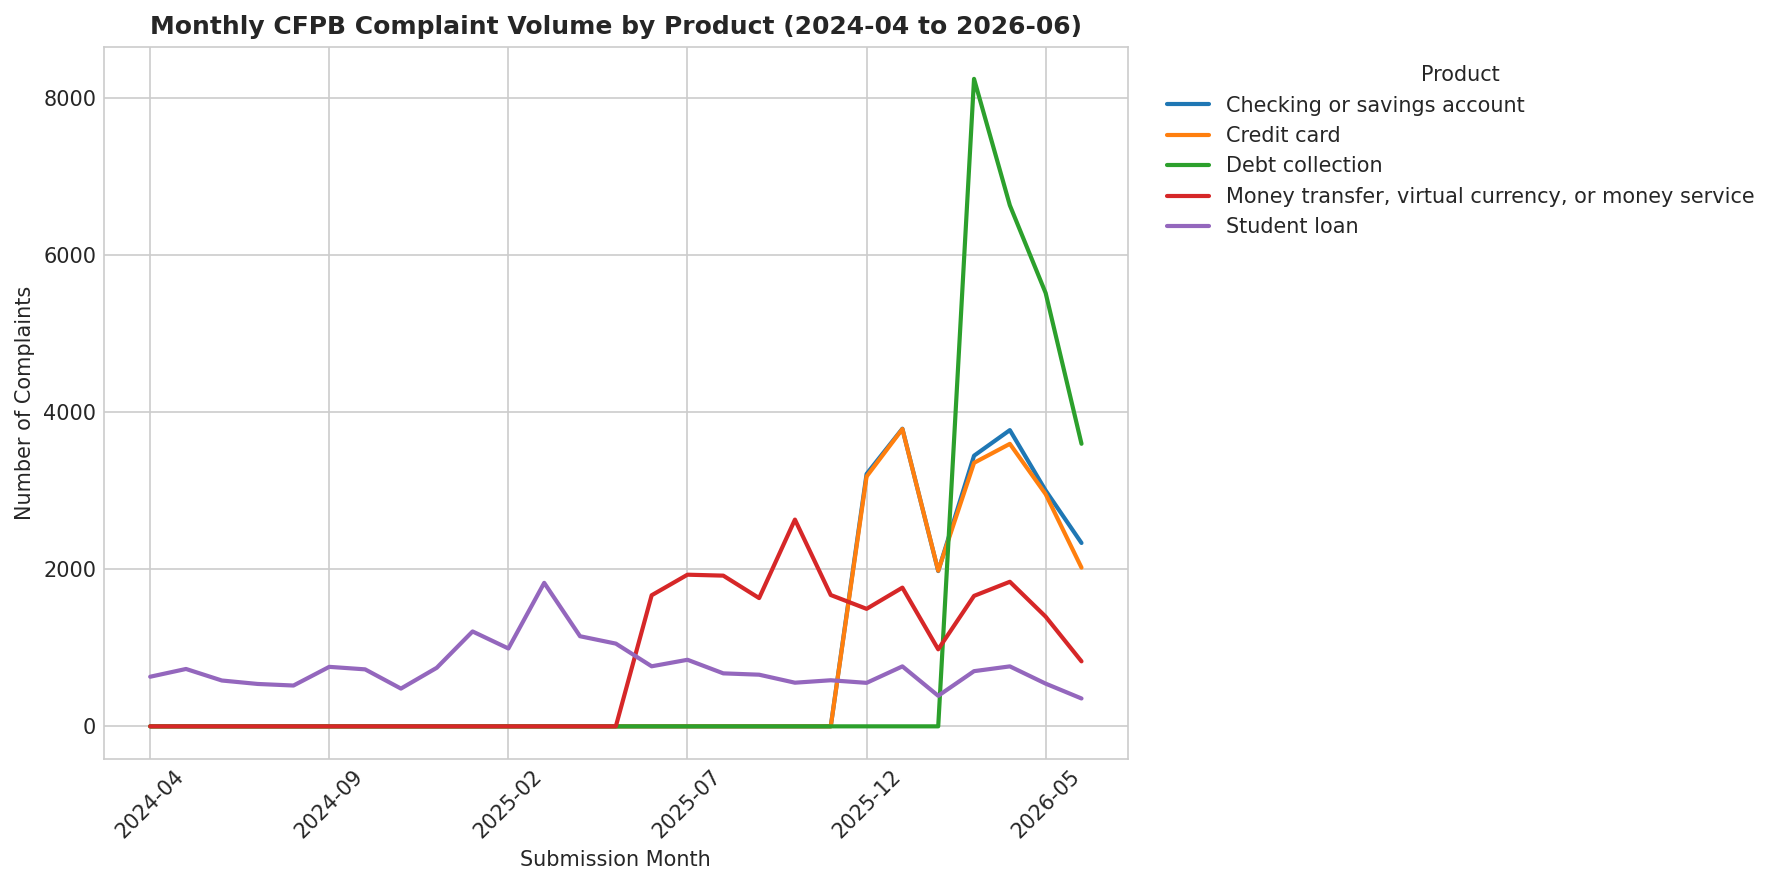

In [11]:
df["year_month"] = df["date_received"].str[:7]
monthly_pivot = df.pivot_table(index="year_month", columns="product", values="complaint_id", aggfunc="count", fill_value=0)

plt.figure(figsize=(12, 6), dpi=150)
monthly_pivot.plot(ax=plt.gca(), linewidth=2.0)
plt.title("Monthly CFPB Complaint Volume by Product (2024-04 to 2026-06)", fontsize=12, fontweight="bold")
plt.xlabel("Submission Month")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Observation
- Because acquisition used the "most recent ~20k" rule in Phase 2B, time spans differ across products:
  - `Debt collection`: 4 months (2026-03 to 2026-06)
  - `Credit card` & `Checking or savings`: 7 months (2025-12 to 2026-06)
  - `Money transfer`: 13 months (2025-06 to 2026-06)
  - `Student loan`: 27 months (2024-04 to 2026-06)

### Decision / Implication
A temporal split across classes is not viable because classes do not share the same date window. The group-stratified split is the correct, statistically valid approach.


## 11. DistilBERT Tokenizer Length Analysis
Evaluate actual sub-word token lengths using `distilbert-base-uncased`.


In [12]:
# Load precomputed tokenization analysis
seq_file = Path("../data/processed/sequence_length_analysis.json")
if not seq_file.exists():
    seq_file = Path("data/processed/sequence_length_analysis.json")

with open(seq_file) as f:
    seq_data = json.load(f)

tok_stats = seq_data["overall"]["distilbert_token_count"]
trunc_rates = seq_data["overall"]["truncation_rates"]

print("=== DistilBERT Sub-Word Token Statistics ===")
for k, v in tok_stats.items():
    print(f"{k:>10}: {v:.1f}" if isinstance(v, float) else f"{k:>10}: {v}")

print("\n=== Truncation Rates for Candidate Max Lengths ===")
trunc_df = pd.DataFrame(trunc_rates).T
display(trunc_df[["max_length", "truncated_count", "truncated_percentage", "retained_percentage"]])


=== DistilBERT Sub-Word Token Statistics ===
     count: 107992
       min: 7.0
       max: 9071.0
      mean: 281.8
       std: 281.3
    median: 215.0
       p25: 120.0
       p75: 358.0
       p90: 550.0
       p95: 720.0
       p99: 1289.0

=== Truncation Rates for Candidate Max Lengths ===


,max_length,truncated_count,truncated_percentage,retained_percentage
64,64.0,97389.0,90.18,9.82
128,128.0,78245.0,72.45,27.55
256,256.0,44775.0,41.46,58.54
512,512.0,12738.0,11.80,88.20


### Observation
- Sub-word token lengths are significantly longer than word counts:
  - Median token length: **215 tokens** (vs 168 whitespace words).
  - 75th percentile: **358 tokens** (vs 280 words).
  - 90th percentile: **550 tokens** (vs 426 words).
- **Truncation rates:**
  - `max_length = 64`: **90.18% truncated** (only 9.82% of complaints fit entirely).
  - `max_length = 128`: **72.45% truncated** (27.55% retained entirely).
  - `max_length = 256`: **41.46% truncated** (58.54% retained entirely).
  - `max_length = 512`: **11.80% truncated** (88.20% retained entirely).

### Decision / Implication
- On CPU-only hardware, quadratic self-attention cost $O(L^2)$ makes $L=512$ or $L=256$ computationally heavy for rapid iteration.
- For initial controlled baselines on CPU, **`max_length = 128`** provides a practical, efficient starting point while capturing key initial grievance sentences.
- Model architecture comparison experiments will evaluate the fairness of sequence truncation across LSTM and DistilBERT.


## 12. Final Modeling Dataset Verification & Artifacts
Verify the final processed partitions (`train`, `validation`, `test`), class weights, and GloVe coverage.


In [13]:
# Load metadata and class weights
meta_file = Path("../data/processed/split_metadata.json")
if not meta_file.exists():
    meta_file = Path("data/processed/split_metadata.json")

cw_file = Path("../data/processed/class_weights.json")
if not cw_file.exists():
    cw_file = Path("data/processed/class_weights.json")

glove_file = Path("../data/processed/glove_coverage.json")
if not glove_file.exists():
    glove_file = Path("data/processed/glove_coverage.json")

with open(meta_file) as f:
    meta = json.load(f)
with open(cw_file) as f:
    cw = json.load(f)
with open(glove_file) as f:
    glove = json.load(f)

print(f"Dataset Version: {meta['dataset_version']}")
print(f"Train Records: {meta['train_records']:,} ({meta['train_records']/meta['total_records']*100:.2f}%)")
print(f"Val Records:   {meta['validation_records']:,} ({meta['validation_records']/meta['total_records']*100:.2f}%)")
print(f"Test Records:  {meta['test_records']:,} ({meta['test_records']/meta['total_records']*100:.2f}%)")
print(f"Leakage Verification: {meta['leakage_verification']}")

print("\n=== Training-Only Class Weights (E3 Preparation) ===")
display(pd.DataFrame(list(cw["weights_by_name"].items()), columns=["Class", "Weight"]))

print("\n=== GloVe 100d Training Vocab Coverage (E2 Preparation) ===")
print(f"Model Vocab Words: {glove['model_vocab_words']:,}")
print(f"GloVe Matched: {glove['matched_words_count']:,} ({glove['vocab_coverage_percentage']}%)")
print(f"Token Frequency Coverage: {glove['token_frequency_coverage_percentage']}%")


Dataset Version: cfpb_phase4_v1
Train Records: 75,598 (70.00%)
Val Records:   16,197 (15.00%)
Test Records:  16,197 (15.00%)
Leakage Verification: {'complaint_id_overlap': 0, 'narrative_group_overlap': 0, 'conflicting_groups_cross_split': 0, 'status': 'PASSED'}

=== Training-Only Class Weights (E3 Preparation) ===


,Class,Weight
0,Checking or savings account,1.002427
1,Credit card,1.033889
2,Debt collection,0.899708
3,"Money transfer, virtual currency, or money ser...",1.007503
4,Student loan,1.073911



=== GloVe 100d Training Vocab Coverage (E2 Preparation) ===
Model Vocab Words: 24,998
GloVe Matched: 20,277 (81.11%)
Token Frequency Coverage: 99.11%


# Why the Final Target is Native CFPB Product Labels

### 1. The Evidence Summary

| Level | Distinct Values | Completeness | Distribution / Quality | Verdict |
|---|---|---|---|---|
| **Product** | **5** | **100% Populated** | **Balanced (1.19x)**, all >20k rows, strong lexical separability | **SELECTED (Option A)** |
| **Sub-product** | 19 | 100% Populated | Uneven (2 to 11 per product); Debt collection top class is **"I do not know" (45.97%)** | **REJECTED** |
| **Issue** | 48 | 100% Populated | **Long-tailed (48 classes)**; 16 classes <500 rows; symptom-level, not routing level | **REJECTED** |
| **Sub-issue** | 134 | **19.96% Missing** | **100% Missing for Money transfer**; undefined for 20% of corpus | **REJECTED** |

### 2. Alignment with Core Business Objective
The task is routing incoming consumer grievances to the appropriate specialized financial product resolution team (`Debt collection`, `Checking or savings account`, `Credit card`, `Money transfer`, or `Student loan`). `Product` directly provides that routing key.

### 3. Rigorous Modeling Foundation
- **Group-Aware Splitting:** 100% containment of exact duplicate boilerplate text (0 leakage).
- **Leakage Prevention:** Class weights and vocabulary fitted strictly on training data.
- **Reproducibility:** Seed 42, deterministic dataset version `cfpb_phase4_v1`.
